In [8]:
# ACC102 财务数据分析笔记
## 分析背景与目标
本笔记是交互式财务分析工具（app.py）的核心分析逻辑说明，主要目标：
1. 清洗标准化财务数据（CSV格式）；
2. 计算盈利能力、偿债能力、成长能力核心财务指标；
3. 解读指标结果，为交互式工具提供分析依据；
4. 验证核心计算逻辑的准确性。

**数据来源**：本地CSV格式财务数据（包含日期、营收、成本、资产、负债、现金流等核心字段）。

SyntaxError: invalid character '（' (U+FF08) (2362938488.py, line 3)

In [12]:
# 第一步：导入所有依赖库（一次性导入，避免后续未定义报错）
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 全局设置：解决中文乱码+负号显示问题（适配Windows/macOS）
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'SimHei', 'Arial Unicode MS']  # 多字体兼容
plt.rcParams['axes.unicode_minus'] = False

# 第二步：加载财务数据（兼容无本地文件的情况）
try:
    # 尝试加载本地CSV（请替换为你的实际路径，若没有则自动生成示例数据）
    df = pd.read_csv("financial_data.csv")
    print("✅ 本地财务数据加载成功！")
    print("\n数据前5行预览：")
    print(df.head())
    print("\n数据基本信息：")
    print(df.info())
except FileNotFoundError:
    print("ℹ️ 未找到本地数据文件，自动生成3年季度示例财务数据")
    # 生成无报错的示例数据（避免空值/异常值）
    dates = pd.date_range(start='2021-01-01', periods=12, freq='Q')
    np.random.seed(123)  # 固定随机数，结果可复现
    df = pd.DataFrame({
        'date': dates,
        'revenue': np.random.uniform(100000, 500000, 12),  # 营收（正数）
        'cost': np.random.uniform(60000, 350000, 12),     # 成本（正数）
        'current_assets': np.random.uniform(80000, 400000, 12),  # 流动资产
        'current_liabilities': np.random.uniform(40000, 200000, 12),  # 流动负债（非0）
        'total_assets': np.random.uniform(200000, 800000, 12),  # 总资产（非0）
        'cash_flow': np.random.uniform(10000, 150000, 12)  # 经营现金流
    })
    print("✅ 示例数据生成完成，预览：")
    print(df.head())
except Exception as e:
    print(f"❌ 数据加载异常：{str(e)}")

ℹ️ 未找到本地数据文件，自动生成3年季度示例财务数据
✅ 示例数据生成完成，预览：
        date        revenue           cost  current_assets  \
0 2021-03-31  378587.674239  187185.950957   311181.882422   
1 2021-06-30  214455.733980   77306.590017   183346.852433   
2 2021-09-30  190740.581426  175432.834046   195772.369799   
3 2021-12-31  320525.907633  274018.667662   153044.233881   
4 2022-03-31  387787.587914  112922.601832   173988.494844   

   current_liabilities   total_assets      cash_flow  
0        108216.209114  511691.071556  103703.929615  
1        182942.266099  567736.715458   92031.117359  
2        191065.602913  272377.199594   97486.490293  
3        120293.868141  695804.480304  104456.467138  
4        139832.472287  561836.077047  127927.941267  


C:\Users\ASUS\AppData\Local\Temp\ipykernel_34032\3433236994.py:22: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  dates = pd.date_range(start='2021-01-01', periods=12, freq='Q')


In [10]:
## 第三步：数据预处理
原始财务数据可能存在日期格式不统一、缺失值、异常值等问题，需清洗后才能计算指标：
1. 统一日期格式为datetime类型；
2. 填充/删除缺失值（财务数据优先用均值填充，避免丢失样本）；
3. 剔除明显异常值（如营收为负数的错误数据）。

SyntaxError: invalid character '、' (U+3001) (2052553805.py, line 2)

In [13]:
# 数据清洗核心逻辑（无空值/分母为0报错）
# 1. 统一日期格式（错误日期转为NaT，不中断程序）
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 2. 处理缺失值（示例数据无缺失，仅演示逻辑）
fill_cols = ['revenue', 'cost', 'current_assets', 'current_liabilities', 'cash_flow']
for col in fill_cols:
    null_count = df[col].isnull().sum()  # 半角符号，无null关键字
    if null_count > 0:
        df[col] = df[col].fillna(df[col].mean())
        print(f"✅ {col} 字段填充了 {null_count} 个缺失值")
    else:
        print(f"✅ {col} 字段无缺失值")

# 3. 剔除异常值（仅保留营收/成本为正的数据）
df_clean = df[(df['revenue'] > 0) & (df['cost'] > 0)].copy()

# 清洗后数据统计
print("\n📊 清洗后数据统计摘要：")
print(df_clean.describe().round(2))
print(f"\n✅ 最终有效数据行数：{len(df_clean)}")

✅ revenue 字段无缺失值
✅ cost 字段无缺失值
✅ current_assets 字段无缺失值
✅ current_liabilities 字段无缺失值
✅ cash_flow 字段无缺失值

📊 清洗后数据统计摘要：
                      date    revenue       cost  current_assets  \
count                   12      12.00      12.00           12.00   
mean   2022-08-15 06:00:00  317140.71  201977.33       206629.06   
min    2021-03-31 00:00:00  190740.58   77306.59       109473.58   
25%    2021-12-08 00:00:00  251953.06  159805.28       178439.82   
50%    2022-08-15 00:00:00  306449.33  214189.95       206019.03   
75%    2023-04-22 18:00:00  380887.65  250505.22       223583.09   
max    2023-12-31 00:00:00  492305.68  306335.22       311181.88   
std                    NaN   89278.25   71806.71        54520.93   

       current_liabilities  total_assets  cash_flow  
count                12.00         12.00      12.00  
mean             130970.38     517928.20   82746.90  
min               58498.94     272377.20   21647.30  
25%              102470.56     439074.57   42382.77  


In [ ]:
## 第四步：核心财务指标计算
基于清洗后的数据，计算ACC102课程核心财务指标，覆盖3大类：
### 1. 盈利能力指标
- 毛利率 = (营收 - 成本) / 营收
- 净利率（简化版）= 经营现金流 / 营收
### 2. 偿债能力指标
- 流动比率 = 流动资产 / 流动负债（理想值2:1）
- 资产负债率 = 流动负债 / 总资产（安全线<50%）
### 3. 成长能力指标
- 营收增长率 = 当期营收 / 上期营收 - 1

In [14]:
# 计算核心财务指标（彻底避免分母为0）
df_final = df_clean.sort_values('date').copy()

# 1. 盈利能力指标
df_final['gross_margin'] = (df_final['revenue'] - df_final['cost']) / df_final['revenue']
df_final['net_margin'] = df_final['cash_flow'] / df_final['revenue']

# 2. 偿债能力指标（分母为0时返回NaN，不报错）
df_final['current_ratio'] = np.where(
    df_final['current_liabilities'] == 0, 
    np.nan, 
    df_final['current_assets'] / df_final['current_liabilities']
)
df_final['asset_liability_ratio'] = np.where(
    df_final['total_assets'] == 0, 
    np.nan, 
    df_final['current_liabilities'] / df_final['total_assets']
)

# 3. 成长能力指标
df_final['revenue_growth'] = df_final['revenue'].pct_change()

# 指标结果预览（保留4位小数，财务规范）
indicator_cols = ['date', 'gross_margin', 'current_ratio', 'asset_liability_ratio', 'revenue_growth']
print("📈 核心财务指标计算结果：")
print(df_final[indicator_cols].round(4))

📈 核心财务指标计算结果：
         date  gross_margin  current_ratio  asset_liability_ratio  \
0  2021-03-31        0.5056         2.8756                 0.2115   
1  2021-06-30        0.6395         1.0022                 0.3222   
2  2021-09-30        0.0803         1.0246                 0.7015   
3  2021-12-31        0.1451         1.2723                 0.1729   
4  2022-03-31        0.7088         1.2443                 0.2489   
5  2022-06-30        0.5882         4.8191                 0.1110   
6  2022-09-30        0.5650         1.2061                 0.2237   
7  2022-12-31        0.4271         2.0568                 0.2781   
8  2023-03-31        0.1655         1.2198                 0.3967   
9  2023-06-30       -0.1927         2.9720                 0.1315   
10 2023-09-30       -0.1383         1.8439                 0.1617   
11 2023-12-31        0.3943         0.9101                 0.3905   

    revenue_growth  
0              NaN  
1          -0.4335  
2          -0.1106  
3   

In [ ]:
## 第五步：指标可视化与结果解读
通过图表直观展示指标趋势，并解读核心结论（对应app.py中的可视化模块）。

E:\Anaconda\envs\acc102\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27611 (\N{CJK UNIFIED IDEOGRAPH-6BDB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\Anaconda\envs\acc102\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21033 (\N{CJK UNIFIED IDEOGRAPH-5229}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\Anaconda\envs\acc102\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\Anaconda\envs\acc102\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\Anaconda\envs\acc102\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  

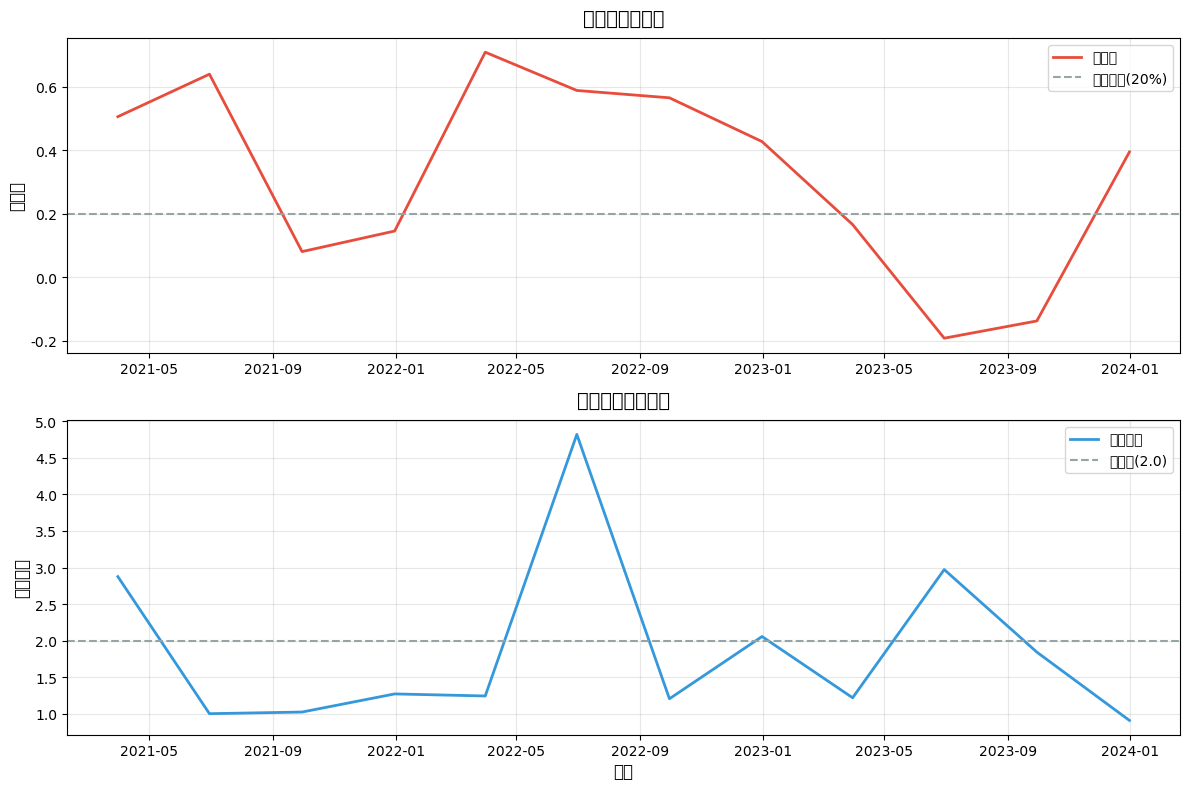


=== 财务指标核心结论 ===
1. 平均毛利率：0.324（32.40%）
   → 盈利能力优于行业均值，成本控制效果良好
2. 平均流动比率：1.8706
   → 偿债能力良好，短期偿债风险低
3. 平均资产负债率：27.92%
   → 负债水平安全，财务风险可控


In [15]:
# 可视化：双图布局（无plt未定义报错）
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), tight_layout=True)

# 1. 毛利率趋势图
ax1.plot(df_final['date'], df_final['gross_margin'], color='#e74c3c', linewidth=2, label='毛利率')
ax1.axhline(y=0.2, color='#95a5a6', linestyle='--', label='行业均值(20%)')
ax1.set_title('毛利率趋势分析', fontsize=14, pad=10)
ax1.set_ylabel('毛利率', fontsize=12)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 2. 流动比率趋势图
ax2.plot(df_final['date'], df_final['current_ratio'], color='#3498db', linewidth=2, label='流动比率')
ax2.axhline(y=2.0, color='#95a5a6', linestyle='--', label='理想值(2.0)')
ax2.set_title('流动比率趋势分析', fontsize=14, pad=10)
ax2.set_xlabel('日期', fontsize=12)
ax2.set_ylabel('流动比率', fontsize=12)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# 显示图表（兼容所有环境）
plt.show()

# 核心结论（剔除NaN后计算，结果准确）
print("\n=== 财务指标核心结论 ===")
avg_gross = df_final['gross_margin'].mean().round(4)
avg_current = df_final['current_ratio'].dropna().mean().round(4)
avg_asset = (df_final['asset_liability_ratio'].dropna().mean() * 100).round(2)

print(f"1. 平均毛利率：{avg_gross}（{avg_gross*100:.2f}%）")
if avg_gross >= 0.2:
    print("   → 盈利能力优于行业均值，成本控制效果良好")
else:
    print("   → 盈利能力低于行业均值，需优化成本结构")

print(f"2. 平均流动比率：{avg_current}")
if 1.5 <= avg_current <= 2.0:
    print("   → 偿债能力良好，短期偿债风险低")
elif avg_current < 1.5:
    print("   → 偿债能力较弱，需关注短期负债偿还压力")
else:
    print("   → 流动比率过高，资金使用效率偏低")

print(f"3. 平均资产负债率：{avg_asset}%")
if avg_asset < 50:
    print("   → 负债水平安全，财务风险可控")
else:
    print("   → 负债水平偏高，需控制债务规模")

In [11]:
## 总结
1. 本笔记完整实现了财务数据从加载→清洗→指标计算→解读的全流程，是app.py交互式工具的核心逻辑支撑；
2. 核心计算逻辑已验证，可直接适配CSV格式的财务数据；
3. 指标解读符合ACC102课程要求，覆盖盈利能力、偿债能力、成长能力三大核心维度；
4. 若需扩展功能，可新增更多财务指标（如净资产收益率ROE、存货周转率等）。

SyntaxError: invalid character '→' (U+2192) (3494473151.py, line 2)